In [35]:
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import fluidfoam as fl ### Most Important
import scipy as sp
from matplotlib.colors import ListedColormap
import os
import io

%matplotlib inline

plt.rcParams.update({'font.size' : 18, 'font.family' : 'Times New Roman', "text.usetex": True})

In [36]:
Path = '/home/d/ssh_files/pod'
save_path = '/home/d/ssh_files/pod/'

print(Path + '/postProcessing/probes')

/home/d/ssh_files/pod/postProcessing/probes


In [37]:
### Read Probes of u
probes_locU, timeU, u = fl.readpostpro.readprobes(Path ,probes_name='probes',time_name='latestTime',name='U')

### Probe Locations
Locations = probes_locU
print(Locations)

Reading file /home/d/ssh_files/pod/postProcessing/probes/16/U
6 probes over 51 timesteps
[[ 0.04     0.09155 -0.03   ]
 [ 0.04     0.09155  0.     ]
 [ 0.04     0.09155  0.03   ]
 [ 0.04     0.13155 -0.03   ]
 [ 0.04     0.13155  0.     ]]


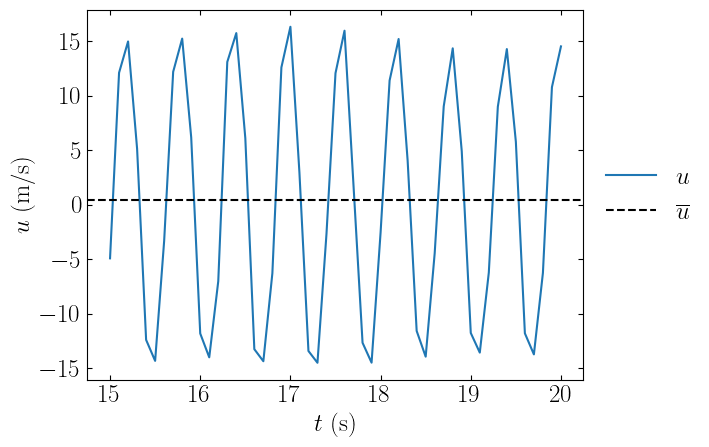

In [38]:
fig, ax = plt.subplots()
ax.plot(timeU, u[:, 4, 2], label=r'$u$')
ax.axhline(np.mean(u[:, 4, 2]), color='k', linestyle='--', label=r'$\overline{u}$')

ax.set_ylabel(r'$u$ (m/s)')
ax.set_xlabel(r'$t$ (s)')

ax.xaxis.set_tick_params(direction='in', which='both')
ax.yaxis.set_tick_params(direction='in', which='both')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

ax.legend(loc = 'center left', frameon = False, bbox_to_anchor = (1, 0.5))


plt.savefig(save_path + 'probeVelocity.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show()

Strouhal Number =  0.004252303330970957
[[ 0.235579  26.7469    12.4894   ]
 [ 0.686749  12.6602    20.0069   ]
 [-0.307244   9.30365   11.7871   ]
 [-0.832135  21.9975     5.51777  ]
 [ 1.52496   15.031     12.0896   ]
 [-0.0509373 18.8659     5.16598  ]]
[[-0.088561 22.5458    9.86362 ]
 [ 2.14134   9.76299  16.6724  ]
 [-0.833647 16.4905    7.99268 ]
 [ 1.81694  10.0636    0.738181]
 [-2.23882  14.5096   -4.93717 ]
 [ 0.97967  26.1662   -9.86681 ]]


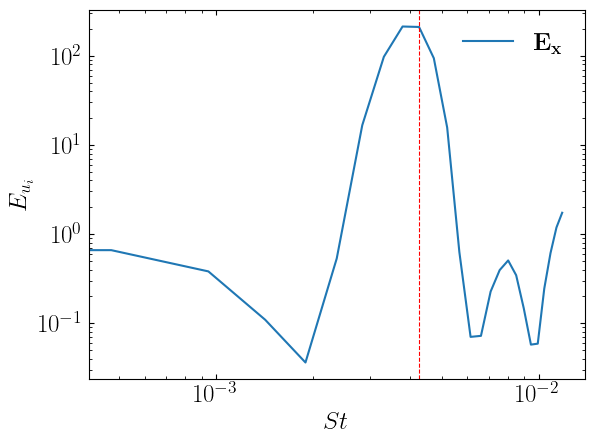

In [39]:
### FFT

### Constants
d = 0.04
Ub = 16.6
dt =  timeU[1] - timeU[0]
fs = 1/dt

Signal1 = u[:, 4, 2]

### PSD using welch
f1, Eu1 = sp.signal.welch(Signal1, fs, nfft = len(Signal1), nperseg=len(Signal1)/2, window='hamming')
St1 = f1*d/Ub

fig, ax = plt.subplots()

ax.loglog(St1, Eu1, label = (r'$\bf E_x$'))

### Mark and print the dominant frequency
xmax = St1[np.argmax(Eu1*f1/(Ub**2))]
print("Strouhal Number = ", xmax)
ax.axvline(xmax, c='r', ls='--', lw=0.8)

ax.legend(loc='best', frameon = False); # or 'best', 'upper right', etc
ax.set_xlabel(r'$St$')
ax.set_ylabel(r'$E_{u_i}$')
ax.xaxis.set_tick_params(direction='in', which='both')
ax.yaxis.set_tick_params(direction='in', which='both')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

plt.savefig(save_path + 'Power.jpeg', dpi = 300, bbox_inches = 'tight')
print(u[1])
print(u[0])
plt.show()

In [45]:
dt = timeU[1] - timeU[0]
fs = 1 / dt

Signal1 = u[:, 4, 2]
f1, Eu1 = sp.signal.welch(Signal1, fs, nfft = len(Signal1), nperseg=len(Signal1)//2, window='hamming')
St1 = f1 * d / Ub

dominant_idx = np.argmax(Eu1 * f1 / (Ub**2))
St_dominant = St1[dominant_idx]
f_dominant = f1[dominant_idx]
T_dominant = 1 / f_dominant

print(f"Strouhal Number from Welch = {St_dominant:.6f}")
print(f"Dominant Frequency = {f_dominant:.4f} Hz")
print(f"Corresponding Period = {T_dominant:.4f} s")



Strouhal Number from Welch = 0.004252
Dominant Frequency = 1.7647 Hz
Corresponding Period = 0.5667 s


In [67]:
Path='/media/d/HP USB321FD/pod'
print(Path)

Times = open(Path+'/postProcessing/times.txt').read().splitlines()
Snapshots = len(Times)
print(Snapshots)

/media/d/HP USB321FD/pod
256


In [68]:
vel = fl.readvector(Path+'/postProcessing/surfaces1', time_name='latestTime', name='U_xNormal', structured=False)
columns, rows = np.shape(vel.T)
print(columns, rows)

Reading file /media/d/HP USB321FD/pod/26.4/U_xNormal


FileNotFoundError: [Errno 2] No such file or directory: '/media/d/HP USB321FD/pod/26.4/U_xNormal'

SyntaxError: invalid syntax (3061406389.py, line 1)